In [1]:
import pandas as pd
df = pd.read_csv("fpl_player_statistics.csv")
df.head
df.describe

<bound method NDFrame.describe of             player_name      club_name position_name  now_cost  total_points  \
0        Erling Haaland       Man City           FWD      14.7           239   
1     Bruno B.Fernandes        Man Utd           MID      10.4           235   
2       Gabriel Gabriel        Arsenal           DEF       7.3           209   
3       Antoine Semenyo       Man City           MID       8.0           202   
4    Morgan Gibbs-White  Nott'm Forest           MID       7.6           188   
..                  ...            ...           ...       ...           ...   
836        Jayden Danns      Liverpool           FWD       4.3             0   
837       Darwin Darwin      Liverpool           FWD       6.5             0   
838        Tyler Morton      Liverpool           MID       4.5             0   
839     James McConnell      Liverpool           MID       4.4             0   
840         Josh Gracey         Wolves           GKP       4.0             0   

     

In [2]:
import pandas as pd 
df2 = pd.read_csv("premier_league_players.csv")
df2.head

<bound method NDFrame.head of         Player Name  Age Market Value                    Club  \
0    Erling Haaland   24     €180.00m         Manchester City   
1       Bukayo Saka   23     €150.00m              Arsenal FC   
2     Florian Wirtz   22     €140.00m            Liverpool FC   
3       Cole Palmer   23     €120.00m              Chelsea FC   
4    Alexander Isak   25     €120.00m        Newcastle United   
..              ...  ...          ...                     ...   
494    Andrew Moran   21        €200k  Brighton & Hove Albion   
495       Karl Hein   23        €175k              Arsenal FC   
496    Lukas Nmecha   26        €150k            Leeds United   
497      James Hill   23        €150k         AFC Bournemouth   
498  Carl Rushworth   24        €100k  Brighton & Hove Albion   

               Position Nationality  
0        Centre-Forward      Norway  
1          Right Winger     England  
2    Attacking Midfield     Germany  
3    Attacking Midfield     England  

In [3]:
import requests
import pandas as pd
import os

API_KEY = "ba28390614fd4b4c99869f11513f147b"

headers = {"X-Auth-Token": API_KEY}

base_url = "https://api.football-data.org/v4"
competition = "PL"
season = 2025

url = "https://api.football-data.org/v4/competitions/PL"

response = requests.get(url, headers=headers)

print(response.status_code)

200


In [4]:
url = f"{base_url}/competitions/{competition}/standings?season={season}"

response = requests.get(url, headers=headers)

standings = response.json()

standings.keys()

dict_keys(['filters', 'area', 'competition', 'season', 'standings'])

In [5]:
table = standings["standings"][0]["table"]

df_standings = pd.json_normalize(table)

df_standings.head()

,position,playedGames,form,won,draw,lost,points,goalsFor,goalsAgainst,goalDifference,team.id,team.name,team.shortName,team.tla,team.crest
0,1,38,"W,W,W,W,W",26,7,5,85,71,27,44,57,Arsenal FC,Arsenal,ARS,https://crests.football-data.org/57.png
1,2,38,"L,D,W,W,D",23,9,6,78,77,35,42,65,Manchester City FC,Man City,MCI,https://crests.football-data.org/65.png
2,3,38,"W,W,D,W,W",20,11,7,71,69,50,19,66,Manchester United FC,Man United,MUN,https://crests.football-data.org/66.png
3,4,38,"W,W,D,L,L",19,8,11,65,56,49,7,58,Aston Villa FC,Aston Villa,AVL,https://crests.football-data.org/58.png
4,5,38,"D,L,D,L,W",17,9,12,60,63,53,10,64,Liverpool FC,Liverpool,LIV,https://crests.football-data.org/64.png


In [6]:
df_standings.columns.tolist()

['position',
 'playedGames',
 'form',
 'won',
 'draw',
 'lost',
 'points',
 'goalsFor',
 'goalsAgainst',
 'goalDifference',
 'team.id',
 'team.name',
 'team.shortName',
 'team.tla',
 'team.crest']

In [7]:
df_standings = df_standings[
    [
        "position",
        "team.name",
        "playedGames",
        "won",
        "draw",
        "lost",
        "points",
        "goalsFor",
        "goalsAgainst",
        "goalDifference",
        "form"
    ]
]

In [8]:
df_standings.columns = [
    "Position",
    "Team",
    "Played",
    "Wins",
    "Draws",
    "Losses",
    "Points",
    "Goals For",
    "Goals Against",
    "Goal Difference",
    "Recent Form"
]

In [9]:
df_standings.head()

,Position,Team,Played,Wins,Draws,Losses,Points,Goals For,Goals Against,Goal Difference,Recent Form
0,1,Arsenal FC,38,26,7,5,85,71,27,44,"W,W,W,W,W"
1,2,Manchester City FC,38,23,9,6,78,77,35,42,"L,D,W,W,D"
2,3,Manchester United FC,38,20,11,7,71,69,50,19,"W,W,D,W,W"
3,4,Aston Villa FC,38,19,8,11,65,56,49,7,"W,W,D,L,L"
4,5,Liverpool FC,38,17,9,12,60,63,53,10,"D,L,D,L,W"


In [10]:
df_standings.to_csv("premier_league_standings.csv", index=False)

In [11]:
url = f"{base_url}/competitions/{competition}/matches?season={season}"

response = requests.get(url, headers=headers)

matches = response.json()

matches.keys()

dict_keys(['filters', 'resultSet', 'competition', 'matches'])

In [12]:
df_matches = pd.json_normalize(matches["matches"])
df_matches.columns.tolist()

['id',
 'utcDate',
 'status',
 'matchday',
 'stage',
 'group',
 'lastUpdated',
 'referees',
 'area.id',
 'area.name',
 'area.code',
 'area.flag',
 'competition.id',
 'competition.name',
 'competition.code',
 'competition.type',
 'competition.emblem',
 'season.id',
 'season.startDate',
 'season.endDate',
 'season.currentMatchday',
 'season.winner',
 'homeTeam.id',
 'homeTeam.name',
 'homeTeam.shortName',
 'homeTeam.tla',
 'homeTeam.crest',
 'awayTeam.id',
 'awayTeam.name',
 'awayTeam.shortName',
 'awayTeam.tla',
 'awayTeam.crest',
 'score.winner',
 'score.duration',
 'score.fullTime.home',
 'score.fullTime.away',
 'score.halfTime.home',
 'score.halfTime.away',
 'odds.msg']

In [13]:
df_matches_clean = df_matches[
    [
        "id",
        "utcDate",
        "status",
        "matchday",
        "homeTeam.name",
        "awayTeam.name",
        "score.winner",
        "score.fullTime.home",
        "score.fullTime.away",
        "score.halfTime.home",
        "score.halfTime.away"
    ]
]

In [14]:
df_matches_clean.columns = [
    "Match ID",
    "Date",
    "Status",
    "Matchday",
    "Home Team",
    "Away Team",
    "Winner",
    "Home Goals",
    "Away Goals",
    "Home HT Goals",
    "Away HT Goals"
]

In [15]:
df_matches_clean.head()

,Match ID,Date,Status,Matchday,Home Team,Away Team,Winner,Home Goals,Away Goals,Home HT Goals,Away HT Goals
0,537785,2025-08-15T19:00:00Z,FINISHED,1,Liverpool FC,AFC Bournemouth,HOME_TEAM,4,2,1,0
1,537786,2025-08-16T11:30:00Z,FINISHED,1,Aston Villa FC,Newcastle United FC,DRAW,0,0,0,0
2,537787,2025-08-16T14:00:00Z,FINISHED,1,Brighton & Hove Albion FC,Fulham FC,DRAW,1,1,0,0
3,537789,2025-08-16T14:00:00Z,FINISHED,1,Sunderland AFC,West Ham United FC,HOME_TEAM,3,0,0,0
4,537790,2025-08-16T14:00:00Z,FINISHED,1,Tottenham Hotspur FC,Burnley FC,HOME_TEAM,3,0,1,0


In [16]:
df_matches_clean.to_csv("premier_league_matches.csv", index=False)

In [17]:
# Rename columns to match df
df2 = df2.rename(columns={
    "Player Name": "player_name",
    "Club": "club_name",
    "Position": "position_name",
    "Age": "age",
    "Market Value": "market_value",
    "Nationality": "nationality"
})
# Remove extra spaces
df["player_name"] = df["player_name"].str.strip()
df2["player_name"] = df2["player_name"].str.strip()

df["club_name"] = df["club_name"].str.strip()
df2["club_name"] = df2["club_name"].str.strip()
master_df = pd.merge(
    df,
    df2,
    on=["player_name", "club_name"],
    how="inner"
)

In [18]:
print(master_df.shape)
master_df.head()

(42, 81)


,player_name,club_name,position_name_x,now_cost,total_points,event_points,points_per_game,selected_by_percent,goals_scored,assists,...,points_per_game_rank,points_per_game_rank_type,selected_rank,selected_rank_type,starts_per_90,clean_sheets_per_90,age,market_value,position_name_y,nationality
0,Morgan Rogers,Aston Villa,MID,7.3,169,0,4.6,20.2,10,8,...,27,12,13,4,1.02,0.25,22,€50.00m,Attacking Midfield,England
1,Ollie Watkins,Aston Villa,FWD,8.7,167,13,4.5,13.0,16,4,...,32,5,28,8,1.05,0.29,29,€35.00m,Centre-Forward,England
2,Maxence Lacroix,Crystal Palace,DEF,5.2,154,0,4.4,7.1,1,2,...,34,11,60,18,1.02,0.32,25,€22.00m,Centre-Back,France
3,Maxence Lacroix,Crystal Palace,DEF,5.2,154,0,4.4,7.1,1,2,...,34,11,60,18,1.02,0.32,25,€20.00m,Centre-Back,France
4,Daniel Muñoz,Crystal Palace,DEF,5.9,136,1,4.7,9.2,4,4,...,24,7,41,13,1.09,0.38,29,€20.00m,Right-Back,Colombia


In [19]:
unmatched = df[~df["player_name"].isin(master_df["player_name"])]

print(unmatched[["player_name", "club_name"]].head(20))

                 player_name      club_name
0             Erling Haaland       Man City
1          Bruno B.Fernandes        Man Utd
2            Gabriel Gabriel        Arsenal
3            Antoine Semenyo       Man City
4         Morgan Gibbs-White  Nott'm Forest
5               Jarrod Bowen       West Ham
6                Declan Rice        Arsenal
7         Igor Thiago Thiago      Brentford
8            Elliot Anderson  Nott'm Forest
9                 Marc Guéhi       Man City
10     João Pedro João Pedro        Chelsea
11             Virgil Virgil      Liverpool
12             Marcos Senesi    Bournemouth
13           James Tarkowski        Everton
15              Harry Wilson         Fulham
17  Carlos Henrique Casemiro        Man Utd
18           Adrien Truffert    Bournemouth
19                David Raya        Arsenal
20             Nico O'Reilly       Man City
21        Dominik Szoboszlai      Liverpool


In [20]:
club_mapping = {
    "Man City": "Manchester City",
    "Man Utd": "Manchester United",
    "Nott'm Forest": "Nottingham Forest",
    "West Ham": "West Ham United",
    "Wolves": "Wolverhampton Wanderers",
    "Bournemouth": "AFC Bournemouth",
    "Chelsea": "Chelsea FC",
    "Arsenal": "Arsenal FC",
    "Liverpool": "Liverpool FC",
    "Brighton": "Brighton & Hove Albion",
    "Newcastle": "Newcastle United",
    "Spurs": "Tottenham Hotspur",
    "Leicester": "Leicester City",
    "Leeds": "Leeds United"
}

df["club_name"] = df["club_name"].replace(club_mapping)

In [21]:
master_df = pd.merge(
    df,
    df2,
    on=["player_name", "club_name"],
    how="inner"
)

print(master_df.shape)

(239, 81)


In [22]:
player_mapping = {
    "Bruno B.Fernandes": "Bruno Fernandes",
    "Gabriel Gabriel": "Gabriel Magalhães",
    "Marc Guéhi": "Marc Guehi",
    "Igor Thiago Thiago": "Igor Thiago",
    "João Pedro João Pedro": "João Pedro"
}

df["player_name"] = df["player_name"].replace(player_mapping)

In [23]:
print(f"FPL players: {len(df)}")
print(f"Market value players: {len(df2)}")
print(f"Merged players: {len(master_df)}")

FPL players: 841
Market value players: 499
Merged players: 239


In [24]:
master_df = pd.merge(
    df,
    df2,
    on=["player_name", "club_name"],
    how="inner"
)

print(f"FPL players: {len(df)}")
print(f"Market value players: {len(df2)}")
print(f"Merged players: {len(master_df)}")

FPL players: 841
Market value players: 499
Merged players: 242


In [25]:
test_merge = pd.merge(
    df,
    df2,
    on="player_name",
    how="inner"
)

print(test_merge.shape)

(347, 82)


In [26]:
master_df = pd.merge(
    df,
    df2,
    on="player_name",
    how="inner",
    suffixes=("_fpl", "_market")
)

print(master_df.shape)
master_df[["player_name", "club_name_fpl", "club_name_market", "market_value"]].head()

(347, 82)


,player_name,club_name_fpl,club_name_market,market_value
0,Erling Haaland,Manchester City,Manchester City,€180.00m
1,Bruno Fernandes,Manchester United,Manchester United,€50.00m
2,Gabriel Magalhães,Arsenal FC,Arsenal FC,€70.00m
3,Antoine Semenyo,Manchester City,AFC Bournemouth,€35.00m
4,Morgan Gibbs-White,Nottingham Forest,Nottingham Forest,€50.00m


In [27]:
master_df.to_csv("master_player_dataset.csv", index=False)

In [28]:
stars = [
    "Mohamed Salah",
    "Bukayo Saka",
    "Cole Palmer",
    "Alexander Isak",
    "Declan Rice",
    "Virgil van Dijk",
    "Phil Foden",
    "Rodri",
    "Martin Ødegaard",
    "Bruno Fernandes"
]

master_df[master_df["player_name"].isin(stars)][
    ["player_name", "club_name_fpl", "market_value"]
]

,player_name,club_name_fpl,market_value
1,Bruno Fernandes,Manchester United,€50.00m
6,Declan Rice,Arsenal FC,€110.00m
19,Bukayo Saka,Arsenal FC,€150.00m
41,Phil Foden,Manchester City,€85.00m
72,Cole Palmer,Chelsea FC,€120.00m
136,Martin Ødegaard,Arsenal FC,€80.00m
205,Alexander Isak,Liverpool FC,€120.00m


In [29]:
missing_market = df2[
    ~df2["player_name"].isin(master_df["player_name"])
]

print(len(missing_market))
missing_market[["player_name", "club_name"]].head(30)

152


,player_name,club_name
6,Rodri,Manchester City
12,Bruno Guimarães,Newcastle United
14,Enzo Fernández,Chelsea FC
18,Josko Gvardiol,Manchester City
20,Luis Díaz,Liverpool FC
23,Rúben Dias,Manchester City
29,Murillo,Nottingham Forest
33,Jurrien Timber,Arsenal FC
40,Micky van de Ven,Tottenham Hotspur
47,Savinho,Manchester City


In [30]:
missing_fpl = df[
    ~df["player_name"].isin(master_df["player_name"])
]

print(len(missing_fpl))
missing_fpl[["player_name", "club_name"]].head(30)

514


,player_name,club_name
9,Marc Guehi,Manchester City
11,Virgil Virgil,Liverpool FC
17,Carlos Henrique Casemiro,Manchester United
19,David Raya,Arsenal FC
23,Enzo Enzo,Chelsea FC
25,Bruno Bruno G.,Newcastle United
26,Matheus Matheus N.,Manchester City
28,Nordi Mukiele,Sunderland
30,Jurriën J.Timber,Arsenal FC
31,Jan Paul Van Hecke,Brighton & Hove Albion


In [31]:
player_mapping = {
    "Marc Guehi": "Marc Guéhi",
    "Virgil Virgil": "Virgil van Dijk",
    "Carlos Henrique Casemiro": "Casemiro",
    "Enzo Enzo": "Enzo Fernández",
    "Bruno Bruno G.": "Bruno Guimarães",
    "Matheus Matheus N.": "Matheus Nunes",
    "Jurriën J.Timber": "Jurrien Timber",
    "Enzo E.Le Fée": "Enzo Le Fée",
    "Dominic Calvert-Lewin": "Dominic Calvert Lewin",
    "Dango O.Dango": "Dango Ouattara",
    "Viktor Gyökeres": "Viktor Gyokeres",
    "Mohamed Salah": "Mohamed Salah",
    "Luis Díaz": "Luis Díaz",
    "Darwin Darwin": "Darwin Núñez",
    "Nicolas Jackson": "Nicolas Jackson",
    "Rodri": "Rodri"
}

df["player_name"] = df["player_name"].replace(player_mapping)
df2["player_name"] = df2["player_name"].replace(player_mapping)

In [32]:
master_df = pd.merge(
    df,
    df2,
    on="player_name",
    how="inner",
    suffixes=("_fpl", "_market")
)

print(master_df.shape)

(357, 82)


In [33]:
missing_market = df2[
    ~df2["player_name"].isin(master_df["player_name"])
]

missing_market[[
    "player_name",
    "club_name"
]].sort_values("club_name")

,player_name,club_name
106,Evanilson,AFC Bournemouth
343,Philip Billing,AFC Bournemouth
216,Hamed Junior Traoré,AFC Bournemouth
285,Eli Junior Kroupi,AFC Bournemouth
363,Julián Araujo,AFC Bournemouth
...,...,...
211,Fábio Silva,Wolverhampton Wanderers
416,José Sá,Wolverhampton Wanderers
143,Toti,Wolverhampton Wanderers
458,Boubacar Traoré,Wolverhampton Wanderers


In [34]:
missing_fpl = df[
    ~df["player_name"].isin(master_df["player_name"])
]

missing_fpl[[
    "player_name",
    "club_name"
]].sort_values("club_name")

,player_name,club_name
658,Zain Silcott-Duberry,AFC Bournemouth
102,Junior Kroupi.Jr,AFC Bournemouth
637,Daniel Adu-Adjei,AFC Bournemouth
640,Remy Rees-Dottin,AFC Bournemouth
641,Malcom DaCosta,AFC Bournemouth
...,...,...
299,Rodrigo R.Gomes,Wolverhampton Wanderers
326,Toti Toti,Wolverhampton Wanderers
309,Jhon J.Arias,Wolverhampton Wanderers
418,Matt Doherty,Wolverhampton Wanderers


In [35]:
stars = [
    "Mohamed Salah",
    "Erling Haaland",
    "Alexander Isak",
    "Bukayo Saka",
    "Cole Palmer",
    "Phil Foden",
    "Rodri",
    "Declan Rice",
    "Bruno Fernandes",
    "Martin Ødegaard",
    "Virgil van Dijk",
    "Bruno Guimarães",
    "Luis Díaz",
    "Enzo Fernández",
    "Josko Gvardiol",
    "Marc Guéhi",
    "Mohamed Kudus",
    "Nicolas Jackson",
    "Amad Diallo",
    "Darwin Núñez"
]

master_df[
    master_df["player_name"].isin(stars)
][["player_name","club_name_fpl","market_value"]].sort_values("player_name")

,player_name,club_name_fpl,market_value
214,Alexander Isak,Liverpool FC,€120.00m
1,Bruno Fernandes,Manchester United,€50.00m
24,Bruno Guimarães,Newcastle United,€75.00m
23,Bukayo Saka,Arsenal FC,€150.00m
81,Cole Palmer,Chelsea FC,€120.00m
355,Darwin Núñez,Liverpool FC,€40.00m
6,Declan Rice,Arsenal FC,€110.00m
22,Enzo Fernández,Chelsea FC,€75.00m
0,Erling Haaland,Manchester City,€180.00m
9,Marc Guéhi,Manchester City,€40.00m


In [36]:
player_mapping = {
    "Junior Kroupi Jr.": "Eli Junior Kroupi",
    "Bruno B.Fernandes": "Bruno Fernandes",
    "Gabriel Gabriel": "Gabriel Magalhães",
    "Marc Guéhi": "Marc Guehi",
    "Igor Thiago Thiago": "Igor Thiago",
    "João Pedro João Pedro": "João Pedro",
    "Carlos Henrique Casemiro": "Casemiro",
    "Virgil Virgil": "Virgil van Dijk",
    "Enzo Enzo": "Enzo Fernández",
    "Bruno Bruno G.": "Bruno Guimarães",
    "Matheus Matheus N.": "Matheus Nunes",
    "Jurriën J.Timber": "Jurrien Timber",
    "Enzo E.Le Fée": "Enzo Le Fée",
    "Dango O.Dango": "Dango Ouattara",
    "Rodrigo R.Gomes": "Rodrigo Gomes",
    "Toti Toti": "Toti",
    "Jhon J.Arias": "Jhon Arias"
}

df["player_name"] = df["player_name"].replace(player_mapping)

In [37]:
master_df = pd.merge(
    df,
    df2,
    on="player_name",
    how="inner",
    suffixes=("_fpl", "_market")
)

print(master_df.shape)

(358, 82)


In [38]:
missing_market = df2[
    ~df2["player_name"].isin(master_df["player_name"])
]

missing_market = missing_market.sort_values(["club_name", "player_name"])

print(f"Remaining Transfermarkt players: {len(missing_market)}")

missing_market[["player_name", "club_name"]]

Remaining Transfermarkt players: 141


,player_name,club_name
285,Eli Junior Kroupi,AFC Bournemouth
365,Enes Ünal,AFC Bournemouth
106,Evanilson,AFC Bournemouth
216,Hamed Junior Traoré,AFC Bournemouth
70,Ilya Zabarnyi,AFC Bournemouth
...,...,...
79,João Gomes,Wolverhampton Wanderers
353,Nasser Djiga,Wolverhampton Wanderers
448,Pedro Lima,Wolverhampton Wanderers
360,Santiago Bueno,Wolverhampton Wanderers


In [39]:
missing_fpl = df[
    ~df["player_name"].isin(master_df["player_name"])
]

missing_fpl = missing_fpl.sort_values(["club_name", "player_name"])

print(f"Remaining FPL players: {len(missing_fpl)}")

missing_fpl[["player_name", "club_name"]]

Remaining FPL players: 503


,player_name,club_name
265,Adam Smith,AFC Bournemouth
808,Alex Paulsen,AFC Bournemouth
454,Alex Tóth.A,AFC Bournemouth
234,Amine Adli,AFC Bournemouth
305,Bafodé Diakité,AFC Bournemouth
...,...,...
506,Saša Kalajdžić,Wolverhampton Wanderers
493,Tawanda Chirewa,Wolverhampton Wanderers
580,Temple Ojinnaka,Wolverhampton Wanderers
238,Tolu Tolu,Wolverhampton Wanderers


In [40]:
pd.set_option("display.max_rows", None)

missing_market = missing_market.sort_values(["club_name", "player_name"])

missing_market[["player_name", "club_name"]]

,player_name,club_name
285,Eli Junior Kroupi,AFC Bournemouth
365,Enes Ünal,AFC Bournemouth
106,Evanilson,AFC Bournemouth
216,Hamed Junior Traoré,AFC Bournemouth
70,Ilya Zabarnyi,AFC Bournemouth
363,Julián Araujo,AFC Bournemouth
343,Philip Billing,AFC Bournemouth
383,Albert Sambi Lokonga,Arsenal FC
62,Ben White,Arsenal FC
207,Fábio Vieira,Arsenal FC


In [41]:
player_mapping.update({
    "Mohamed M.Salah": "Mohamed Salah",
    "Micky van de Ven": "Micky van de Ven",
    "Pedro Porro": "Pedro Porro",
    "Junior Kroupi Jr.": "Eli Junior Kroupi",
    "Ben White": "Ben White",
    "Gabriel Jesus": "Gabriel Jesus",
    "Kaoru Mitoma": "Kaoru Mitoma",
    "Emiliano Martínez": "Emiliano Martínez",
    "Renato Veiga": "Renato Veiga",
    "Marc Guehi": "Marc Guéhi",
    "Alisson Becker": "Alisson",
    "Bernardo Silva": "Bernardo Silva",
    "Josko Gvardiol": "Josko Gvardiol",
    "Savinho": "Savinho",
    "Rodri": "Rodri",
    "Ruben Dias": "Rúben Dias",
    "Amad Diallo": "Amad Diallo",
    "Lisandro Martinez": "Lisandro Martínez",
    "Matthijs de Ligt": "Matthijs de Ligt"
})

In [42]:
pd.set_option("display.max_rows", None)

missing_fpl = missing_fpl.sort_values(["club_name", "player_name"])

missing_fpl[["player_name", "club_name"]]

,player_name,club_name
265,Adam Smith,AFC Bournemouth
808,Alex Paulsen,AFC Bournemouth
454,Alex Tóth.A,AFC Bournemouth
234,Amine Adli,AFC Bournemouth
305,Bafodé Diakité,AFC Bournemouth
435,Ben Gannon-Doak,AFC Bournemouth
529,Ben Winterburn,AFC Bournemouth
807,Callan McKenna,AFC Bournemouth
645,Charlie Stevens,AFC Bournemouth
650,Christos Mandas,AFC Bournemouth


In [43]:
player_mapping.update({
    "Enes Enes Ünal": "Enes Ünal",
    "Francisco Evanilson Evanilson": "Evanilson",
    "Hamed H.Traorè": "Hamed Junior Traoré",
    "Illia Zabarnyi": "Ilya Zabarnyi",
    "Julián J.Araujo": "Julián Araujo",
    "Junior Kroupi.Jr": "Eli Junior Kroupi",
    "Philip Philip": "Philip Billing",

    "Benjamin White": "Ben White",
    "Gabriel G.Jesus": "Gabriel Jesus",
    "Fábio Fábio Vieira": "Fábio Vieira",
    "Viktor Gyökeres": "Viktor Gyokeres",

    "Emiliano Martínez": "Emiliano Martínez",
    "Samuel Illing Jr": "Samuel Iling-Junior",
    "Tammy Abraham": "Tammy Abraham",
    "Victor Lindelöf": "Victor Lindelöf",
    "Álex Alex Moreno": "Álex Moreno",

    "Mohamed M.Salah": "Mohamed Salah",
    "Luis Luis Díaz": "Luis Díaz",
    "Curtis C.Jones": "Curtis Jones",
    "Endo Endo": "Wataru Endo",
    "Alisson Becker": "Alisson",

    "Bernardo Bernardo": "Bernardo Silva",
    "Ederson Ederson M.": "Ederson",
    "Joško Gvardiol": "Josko Gvardiol",
    "Rodrigo 'Rodri' Rodrigo": "Rodri",
    "Rúben Rúben": "Rúben Dias",
    "Sávio Savinho": "Savinho",
    "Vitor Vitor Reis": "Vitor Reis",

    "Amad Amad": "Amad Diallo",
    "Antony Antony": "Antony",
    "Diego D.Leon": "Diego León",
    "Lisandro Martínez": "Lisandro Martínez",
    "Matthijs de Ligt": "Matthijs de Ligt",

    "Jacob J.Murphy": "Jacob Murphy"
})

In [44]:
df["player_name"] = df["player_name"].replace(player_mapping)

master_df = pd.merge(
    df,
    df2,
    on="player_name",
    how="inner",
    suffixes=("_fpl", "_market")
)

print(master_df.shape)

(386, 82)


In [45]:
master_df.to_csv("master_player_dataset.csv", index=False)

In [46]:
missing_market = (
    df2[~df2["player_name"].isin(master_df["player_name"])]
    .sort_values(["club_name", "player_name"])
)

print(len(missing_market))
missing_market[["player_name", "club_name"]]

113


,player_name,club_name
383,Albert Sambi Lokonga,Arsenal FC
418,Andrés García,Aston Villa
235,Emiliano Martínez,Aston Villa
119,Jacob Ramsey,Aston Villa
346,Kosta Nedeljkovic,Aston Villa
121,Pau Torres,Aston Villa
372,Samuel Iling-Junior,Aston Villa
405,Yasin Özcan,Aston Villa
200,Sepp van den Berg,Brentford FC
288,Yegor Yarmolyuk,Brentford FC


In [47]:
player_mapping.update({
    "Renato Renato Veiga": "Renato Veiga",
    "Jan Paul Van Hecke": "Jan Paul van Hecke",
    "Igor Thiago Thiago": "Igor Thiago",
    "Mamadou Mamadou Sarr": "Mamadou Sarr",
    "Matthijs de Ligt": "Matthijs de Ligt",
    "Micky Micky van de Ven": "Micky van de Ven",
    "Pedro Pedro Porro": "Pedro Porro",
    "Lucas Lucas Paquetá": "Lucas Paquetá",
    "Richarlison Richarlison": "Richarlison"
})

In [48]:
df["player_name"] = df["player_name"].replace(player_mapping)

master_df = pd.merge(
    df,
    df2,
    on="player_name",
    how="inner",
    suffixes=("_fpl", "_market")
)

print(master_df.shape)

(388, 82)


In [49]:
big_names = [
    "Mohamed Salah","Rodri","Rúben Dias","Bernardo Silva","Josko Gvardiol",
    "Savinho","Micky van de Ven","Pedro Porro","Lucas Paquetá",
    "Richarlison","Matthijs de Ligt","Gabriel Jesus","Ben White",
    "Marc Guéhi","Emiliano Martínez","Renato Veiga","Mitoma",
    "Alisson","Luis Díaz","Curtis Jones"
]

for name in big_names:
    if name not in master_df["player_name"].values:
        print(name)

Micky van de Ven
Lucas Paquetá
Matthijs de Ligt
Marc Guéhi
Emiliano Martínez
Renato Veiga
Mitoma
Alisson


In [50]:
master_df = pd.merge(
    df,
    df2[["player_name", "market_value"]],
    on="player_name",
    how="left"
)

In [51]:
master_df["market_value"].notna().sum()

np.int64(388)

In [52]:
print(master_df.shape)

(861, 78)


In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = master_df.copy()

In [54]:
df.head()

,player_name,club_name,position_name,now_cost,total_points,event_points,points_per_game,selected_by_percent,goals_scored,assists,...,now_cost_rank_type,form_rank,form_rank_type,points_per_game_rank,points_per_game_rank_type,selected_rank,selected_rank_type,starts_per_90,clean_sheets_per_90,market_value
0,Erling Haaland,Manchester City,FWD,14.7,239,0,6.8,62.5,27,8,...,1,841,95,2,1,1,1,1.04,0.40,€180.00m
1,Bruno Fernandes,Manchester United,MID,10.4,235,14,6.7,48.0,9,24,...,2,839,378,3,1,2,1,1.03,0.21,€50.00m
2,Gabriel Magalhães,Arsenal FC,DEF,7.3,209,1,6.5,45.4,3,5,...,1,816,270,4,1,4,1,0.98,0.59,€70.00m
3,Antoine Semenyo,Manchester City,MID,8.0,202,6,5.5,46.2,17,6,...,12,827,370,5,2,3,2,1.04,0.34,€35.00m
4,Morgan Gibbs-White,Nottingham Forest,MID,7.6,188,9,5.1,9.2,15,4,...,14,821,366,11,5,42,14,1.02,0.29,€50.00m


In [55]:
df.tail()

,player_name,club_name,position_name,now_cost,total_points,event_points,points_per_game,selected_by_percent,goals_scored,assists,...,now_cost_rank_type,form_rank,form_rank_type,points_per_game_rank,points_per_game_rank_type,selected_rank,selected_rank_type,starts_per_90,clean_sheets_per_90,market_value
856,Jayden Danns,Liverpool FC,FWD,4.3,0,0,0.0,0.1,0,0,...,87,239,8,671,70,482,69,0.0,0.0,NaN
857,Darwin Núñez,Liverpool FC,FWD,6.5,0,0,0.0,0.1,0,0,...,19,789,77,837,94,560,77,0.0,0.0,€40.00m
858,Tyler Morton,Liverpool FC,MID,4.5,0,0,0.0,0.0,0,0,...,257,340,57,715,280,817,361,0.0,0.0,€2.50m
859,James McConnell,Liverpool FC,MID,4.4,0,0,0.0,0.0,0,0,...,334,288,32,689,265,691,277,0.0,0.0,NaN
860,Josh Gracey,Wolverhampton Wanderers,GKP,4.0,0,0,0.0,0.0,0,0,...,68,163,60,649,89,772,91,0.0,0.0,NaN


In [56]:
df.describe()

,now_cost,total_points,event_points,points_per_game,selected_by_percent,goals_scored,assists,minutes,clean_sheets,goals_conceded,...,now_cost_rank,now_cost_rank_type,form_rank,form_rank_type,points_per_game_rank,points_per_game_rank_type,selected_rank,selected_rank_type,starts_per_90,clean_sheets_per_90
count,861.000000,861.000000,861.000000,861.000000,861.000000,861.000000,861.000000,861.000000,861.000000,861.000000,...,861.000000,861.000000,861.000000,861.000000,861.000000,861.000000,861.000000,861.000000,861.000000,861.000000
mean,4.886527,41.713124,1.038328,1.672706,1.798374,1.225319,1.137050,906.945412,2.728223,13.921022,...,415.721254,138.578397,426.286876,142.271777,417.630662,139.102207,418.065041,139.108014,0.570128,0.139768
std,1.061364,50.533274,2.139804,1.557901,5.266877,2.718645,2.073596,1066.540947,3.719903,16.408826,...,243.302322,102.540054,243.317335,103.359209,244.151908,102.991584,243.595138,102.764469,0.528622,0.165806
min,3.700000,0.000000,-2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,4.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,205.000000,52.000000,216.000000,54.000000,207.000000,52.000000,205.000000,52.000000,0.000000,0.000000
50%,4.500000,16.000000,0.000000,1.600000,0.200000,0.000000,0.000000,367.000000,0.000000,7.000000,...,412.000000,112.000000,430.000000,118.000000,414.000000,112.000000,418.000000,112.000000,0.850000,0.000000
75%,5.200000,74.000000,1.000000,2.900000,0.900000,1.000000,2.000000,1730.000000,5.000000,26.000000,...,626.000000,217.000000,637.000000,224.000000,629.000000,218.000000,628.000000,218.000000,1.010000,0.270000
max,14.700000,239.000000,18.000000,7.000000,62.500000,27.000000,24.000000,3420.000000,19.000000,71.000000,...,841.000000,379.000000,841.000000,379.000000,841.000000,379.000000,841.000000,379.000000,4.740000,1.000000


In [57]:
df.isnull().sum().sort_values(ascending=False)

penalties_text                          861
corners_and_indirect_freekicks_text     861
direct_freekicks_text                   861
direct_freekicks_order                  799
penalties_order                         797
corners_and_indirect_freekicks_order    784
news                                    576
market_value                            473
form_rank_type                            0
ict_index_rank_type                       0
tackles                                   0
clearances_blocks_interceptions           0
recoveries                                0
defensive_contribution                    0
defensive_contribution_per_90             0
clean_sheets_per_90                       0
influence_rank                            0
influence_rank_type                       0
creativity_rank                           0
creativity_rank_type                      0
threat_rank                               0
threat_rank_type                          0
ict_index_rank                  

In [58]:
cols_to_drop = [
    "news",
    "penalties_text",
    "corners_and_indirect_freekicks_text",
    "direct_freekicks_text",
    "penalties_order",
    "corners_and_indirect_freekicks_order",
    "direct_freekicks_order"
]

df = master_df.drop(columns=cols_to_drop)

In [59]:
df.isnull().sum().sort_values(ascending=False).head(10)

market_value                     473
defensive_contribution_per_90      0
threat_rank_type                   0
threat_rank                        0
creativity_rank_type               0
creativity_rank                    0
influence_rank_type                0
influence_rank                     0
defensive_contribution             0
ict_index_rank_type                0
dtype: int64

In [60]:
master_df.shape

(861, 78)

In [61]:
df["player_name"].head(1000)

0                      Erling Haaland
1                     Bruno Fernandes
2                   Gabriel Magalhães
3                     Antoine Semenyo
4                  Morgan Gibbs-White
5                        Jarrod Bowen
6                         Declan Rice
7                         Igor Thiago
8                     Elliot Anderson
9                          Marc Guehi
10                         João Pedro
11                    Virgil van Dijk
12                      Marcos Senesi
13                    James Tarkowski
14                      Morgan Rogers
15                       Harry Wilson
16                      Ollie Watkins
17                           Casemiro
18                    Adrien Truffert
19                         David Raya
20                      Nico O'Reilly
21                 Dominik Szoboszlai
22                       James Garner
23                     Enzo Fernández
24                        Bukayo Saka
25                    Bruno Guimarães
26          

In [62]:
duplicates = df[df.duplicated("player_name", keep=False)] \
    .sort_values("player_name")

duplicates[["player_name", "club_name", "position_name"]]

,player_name,club_name,position_name
289,Andrew Robertson,Liverpool FC,DEF
288,Andrew Robertson,Liverpool FC,DEF
334,Armando Broja,Burnley,FWD
333,Armando Broja,Burnley,FWD
376,Brajan Gruda,Brighton & Hove Albion,MID
377,Brajan Gruda,Brighton & Hove Albion,MID
732,Cheick Doucouré,Crystal Palace,MID
731,Cheick Doucouré,Crystal Palace,MID
121,Crysencio Summerville,West Ham United,MID
120,Crysencio Summerville,West Ham United,MID


In [63]:
duplicate_rows = df[df.duplicated(subset="player_name", keep=False)]

duplicate_rows.groupby("player_name").nunique().T

player_name,Andrew Robertson,Armando Broja,Brajan Gruda,Cheick Doucouré,Crysencio Summerville,Daichi Kamada,Daniel Muñoz,Dominic Solanke,Donyell Malen,Evan Ferguson,Iliman Ndiaye,Ismaïla Sarr,Leandro Trossard,Lesley Ugochukwu,Matty Cash,Maxence Lacroix,Tino Livramento,Trevoh Chalobah,Wesley Fofana,İlkay Gündoğan
club_name,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
position_name,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
now_cost,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
total_points,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
event_points,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
points_per_game,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
selected_by_percent,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
goals_scored,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
assists,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
minutes,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


In [64]:
df = (
    df.sort_values("market_value", na_position="last")
      .drop_duplicates(subset="player_name", keep="first")
      .reset_index(drop=True)
)

print(df.shape)

(841, 71)


In [65]:
#PHASE 2
print(f"Players: {len(df)}")
print(f"Features: {df.shape[1]}")

df.describe()

Players: 841
Features: 71


,now_cost,total_points,event_points,points_per_game,selected_by_percent,goals_scored,assists,minutes,clean_sheets,goals_conceded,...,now_cost_rank,now_cost_rank_type,form_rank,form_rank_type,points_per_game_rank,points_per_game_rank_type,selected_rank,selected_rank_type,starts_per_90,clean_sheets_per_90
count,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,...,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000,841.000000
mean,4.871581,40.882283,1.045184,1.647681,1.779905,1.195006,1.120095,890.073722,2.673008,13.668252,...,421.000000,140.199762,421.000000,140.199762,421.000000,140.199762,421.000000,140.199762,0.563888,0.137765
std,1.064039,50.303358,2.152043,1.552892,5.305423,2.716357,2.080771,1062.254447,3.697663,16.342118,...,242.920083,102.844175,242.920083,102.844175,242.920083,102.844175,242.920083,102.844175,0.530399,0.165754
min,3.700000,0.000000,-2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,4.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,211.000000,53.000000,211.000000,53.000000,211.000000,53.000000,211.000000,53.000000,0.000000,0.000000
50%,4.500000,14.000000,0.000000,1.500000,0.100000,0.000000,0.000000,319.000000,0.000000,6.000000,...,421.000000,115.000000,421.000000,115.000000,421.000000,115.000000,421.000000,115.000000,0.840000,0.000000
75%,5.200000,74.000000,1.000000,2.900000,0.900000,1.000000,2.000000,1697.000000,5.000000,25.000000,...,631.000000,220.000000,631.000000,220.000000,631.000000,220.000000,631.000000,220.000000,1.010000,0.270000
max,14.700000,239.000000,18.000000,7.000000,62.500000,27.000000,24.000000,3420.000000,19.000000,71.000000,...,841.000000,379.000000,841.000000,379.000000,841.000000,379.000000,841.000000,379.000000,4.740000,1.000000


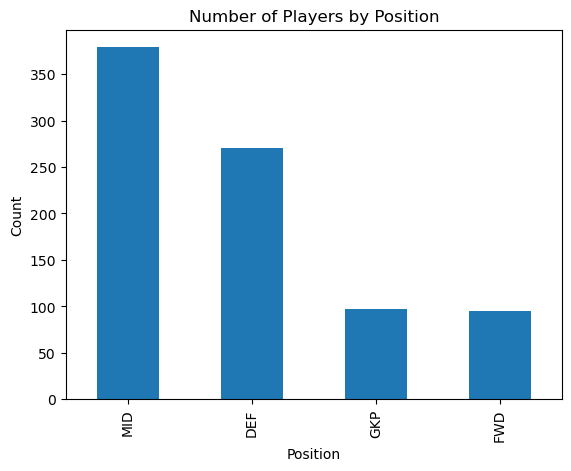

In [66]:
import matplotlib.pyplot as plt 

df["position_name"].value_counts().plot(kind="bar")

plt.title("Number of Players by Position")
plt.xlabel("Position")
plt.ylabel("Count")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

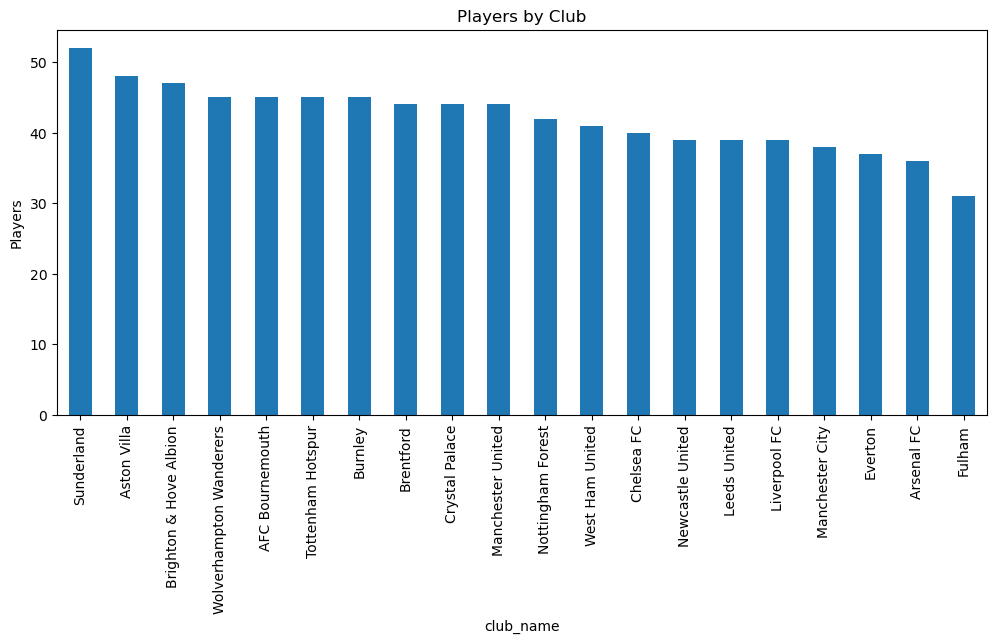

In [67]:
club_counts = df["club_name"].value_counts()

club_counts.plot(figsize=(12,5), kind="bar")
plt.title("Players by Club")
plt.ylabel("Players")
plt.show

In [68]:
import numpy as np
import pandas as pd

# Work from the cleaned dataframe
model_df = df.copy()

# Convert minutes into 90-minute matches
model_df["nineties"] = model_df["minutes"] / 90

# Avoid division by zero for players with no minutes
model_df["nineties"] = model_df["nineties"].replace(0, np.nan)

# Create additional per-90 playing-style features
model_df["goals_per_90"] = (
    model_df["goals_scored"] / model_df["nineties"]
)

model_df["assists_per_90"] = (
    model_df["assists"] / model_df["nineties"]
)

model_df["tackles_per_90"] = (
    model_df["tackles"] / model_df["nineties"]
)

model_df["recoveries_per_90"] = (
    model_df["recoveries"] / model_df["nineties"]
)

model_df["clearances_blocks_interceptions_per_90"] = (
    model_df["clearances_blocks_interceptions"] /
    model_df["nineties"]
)

# Replace undefined values for players with no minutes
new_per90_features = [
    "goals_per_90",
    "assists_per_90",
    "tackles_per_90",
    "recoveries_per_90",
    "clearances_blocks_interceptions_per_90"
]

model_df[new_per90_features] = (
    model_df[new_per90_features]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

model_df[new_per90_features].describe()

,goals_per_90,assists_per_90,tackles_per_90,recoveries_per_90,clearances_blocks_interceptions_per_90
count,841.000000,841.000000,841.000000,841.000000,841.000000
mean,0.076214,0.073404,1.099097,2.785847,2.373632
std,0.293048,0.234158,2.238956,3.196370,5.382322
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.631025,2.803115,1.210526
75%,0.076401,0.102681,1.739130,4.394366,3.283262
max,7.500000,5.625000,45.000000,45.000000,90.000000


In [69]:
feature_groups = {
    "attacking": [
        "goals_per_90",
        "expected_goals_per_90",
        "threat"
    ],

    "creation": [
        "assists_per_90",
        "expected_assists_per_90",
        "creativity"
    ],

    "overall_attacking_involvement": [
        "expected_goal_involvements_per_90",
        "influence"
    ],

    "defending": [
        "tackles_per_90",
        "recoveries_per_90",
        "clearances_blocks_interceptions_per_90",
        "defensive_contribution_per_90"
    ]
}

for group, features in feature_groups.items():
    print(f"{group.upper()}:")
    for feature in features:
        print(f"  - {feature}")

ATTACKING:
  - goals_per_90
  - expected_goals_per_90
  - threat
CREATION:
  - assists_per_90
  - expected_assists_per_90
  - creativity
OVERALL_ATTACKING_INVOLVEMENT:
  - expected_goal_involvements_per_90
  - influence
DEFENDING:
  - tackles_per_90
  - recoveries_per_90
  - clearances_blocks_interceptions_per_90
  - defensive_contribution_per_90


In [70]:

metadata_columns = [
    "player_name",
    "club_name",
    "position_name",
    "minutes",
    "market_value"
]

# Flatten the feature groups into one master feature list
model_features = [
    feature
    for group in feature_groups.values()
    for feature in group
]

print(f"Metadata columns: {len(metadata_columns)}")
print(f"Model features: {len(model_features)}")
print(model_features)

Metadata columns: 5
Model features: 12
['goals_per_90', 'expected_goals_per_90', 'threat', 'assists_per_90', 'expected_assists_per_90', 'creativity', 'expected_goal_involvements_per_90', 'influence', 'tackles_per_90', 'recoveries_per_90', 'clearances_blocks_interceptions_per_90', 'defensive_contribution_per_90']


In [71]:
MINIMUM_MINUTES = 450

eligible_players = model_df[
    model_df["minutes"] >= MINIMUM_MINUTES
].copy()

print(f"Players before minutes filter: {len(model_df)}")
print(f"Players after minutes filter: {len(eligible_players)}")

Players before minutes filter: 841
Players after minutes filter: 400


In [72]:
# Keep only columns that actually exist
available_features = [
    feature
    for feature in model_features
    if feature in eligible_players.columns
]

missing_features = [
    feature
    for feature in model_features
    if feature not in eligible_players.columns
]

print("Available features:")
print(available_features)

print("\nMissing features:")
print(missing_features)

# Metadata used when displaying results
player_information = eligible_players[
    metadata_columns
].reset_index(drop=True)

# Numerical feature matrix used for modeling
X = eligible_players[
    available_features
].copy()

# Clean unexpected infinite or missing values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

print("\nFeature matrix shape:", X.shape)
X.head()

Available features:
['goals_per_90', 'expected_goals_per_90', 'threat', 'assists_per_90', 'expected_assists_per_90', 'creativity', 'expected_goal_involvements_per_90', 'influence', 'tackles_per_90', 'recoveries_per_90', 'clearances_blocks_interceptions_per_90', 'defensive_contribution_per_90']

Missing features:
[]

Feature matrix shape: (400, 12)


,goals_per_90,expected_goals_per_90,threat,assists_per_90,expected_assists_per_90,creativity,expected_goal_involvements_per_90,influence,tackles_per_90,recoveries_per_90,clearances_blocks_interceptions_per_90,defensive_contribution_per_90
3,0.104328,0.08,299.0,0.034776,0.02,47.4,0.10,770.4,1.286708,3.025502,9.215611,10.50
7,0.074938,0.05,52.0,0.000000,0.01,11.1,0.06,276.4,1.049126,2.997502,7.943381,8.99
11,0.031724,0.06,210.0,0.031724,0.02,125.5,0.08,649.6,1.110328,4.282693,6.217836,7.33
12,0.114650,0.27,168.0,0.000000,0.04,101.8,0.31,115.0,2.866242,3.898089,1.490446,8.25
15,0.319905,0.17,191.0,0.213270,0.13,162.3,0.30,227.8,1.492891,4.798578,1.599526,7.89


In [73]:
feature_variation = X.nunique().sort_values()

constant_features = feature_variation[
    feature_variation <= 1
].index.tolist()

print("Constant features:", constant_features)

if constant_features:
    X = X.drop(columns=constant_features)
    available_features = [
        feature
        for feature in available_features
        if feature not in constant_features
    ]

print("Updated feature matrix shape:", X.shape)

Constant features: []
Updated feature matrix shape: (400, 12)


In [74]:
correlation_matrix = X.corr().abs()

upper_triangle = correlation_matrix.where(
    np.triu(
        np.ones(correlation_matrix.shape),
        k=1
    ).astype(bool)
)

highly_correlated_pairs = []

for column in upper_triangle.columns:
    correlated_features = upper_triangle.index[
        upper_triangle[column] > 0.90
    ].tolist()

    for feature in correlated_features:
        highly_correlated_pairs.append(
            {
                "feature_1": feature,
                "feature_2": column,
                "correlation": upper_triangle.loc[feature, column]
            }
        )

correlated_df = pd.DataFrame(highly_correlated_pairs)

if correlated_df.empty:
    print("No feature pairs have correlation above 0.90.")
else:
    display(
        correlated_df.sort_values(
            "correlation",
            ascending=False
        )
    )

,feature_1,feature_2,correlation
0,expected_goals_per_90,expected_goal_involvements_per_90,0.917333


In [75]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

print("Scaled feature matrix shape:", X_scaled_df.shape)

X_scaled_df.describe().round(2)

Scaled feature matrix shape: (400, 12)


,goals_per_90,expected_goals_per_90,threat,assists_per_90,expected_assists_per_90,creativity,expected_goal_involvements_per_90,influence,tackles_per_90,recoveries_per_90,clearances_blocks_interceptions_per_90,defensive_contribution_per_90
count,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00
mean,-0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.79,-0.95,-1.05,-1.03,-1.20,-1.12,-1.27,-1.50,-1.78,-1.86,-1.31,-2.32
25%,-0.79,-0.66,-0.71,-0.80,-0.77,-0.73,-0.74,-0.82,-0.69,-0.65,-0.80,-0.56
50%,-0.31,-0.34,-0.25,-0.16,-0.19,-0.27,-0.27,-0.16,-0.04,-0.15,-0.31,0.04
75%,0.32,0.27,0.34,0.48,0.54,0.47,0.56,0.63,0.60,0.44,0.55,0.69
max,4.64,4.64,5.46,5.09,5.33,6.89,3.82,3.57,3.65,3.43,3.90,2.49


## Phase 4: Feature Standardization

Before clustering, the selected features are standardized so that each variable contributes equally to the distance calculations used by K-Means. Standardization transforms each feature to have a mean of 0 and a standard deviation of 1.


In [76]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

print("Feature matrix shape:", X_scaled.shape)

X_scaled.describe().round(2)

Feature matrix shape: (400, 12)


,goals_per_90,expected_goals_per_90,threat,assists_per_90,expected_assists_per_90,creativity,expected_goal_involvements_per_90,influence,tackles_per_90,recoveries_per_90,clearances_blocks_interceptions_per_90,defensive_contribution_per_90
count,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00
mean,-0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.79,-0.95,-1.05,-1.03,-1.20,-1.12,-1.27,-1.50,-1.78,-1.86,-1.31,-2.32
25%,-0.79,-0.66,-0.71,-0.80,-0.77,-0.73,-0.74,-0.82,-0.69,-0.65,-0.80,-0.56
50%,-0.31,-0.34,-0.25,-0.16,-0.19,-0.27,-0.27,-0.16,-0.04,-0.15,-0.31,0.04
75%,0.32,0.27,0.34,0.48,0.54,0.47,0.56,0.63,0.60,0.44,0.55,0.69
max,4.64,4.64,5.46,5.09,5.33,6.89,3.82,3.57,3.65,3.43,3.90,2.49


In [77]:
summary = pd.DataFrame({
    "Mean": X_scaled.mean(),
    "Std Dev": X_scaled.std()
})

summary.round(3)

,Mean,Std Dev
goals_per_90,-0.0,1.001
expected_goals_per_90,0.0,1.001
threat,-0.0,1.001
assists_per_90,-0.0,1.001
expected_assists_per_90,0.0,1.001
creativity,0.0,1.001
expected_goal_involvements_per_90,0.0,1.001
influence,-0.0,1.001
tackles_per_90,-0.0,1.001
recoveries_per_90,-0.0,1.001


In [78]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

k_values = range(2, 11)

inertia = []
silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)

    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

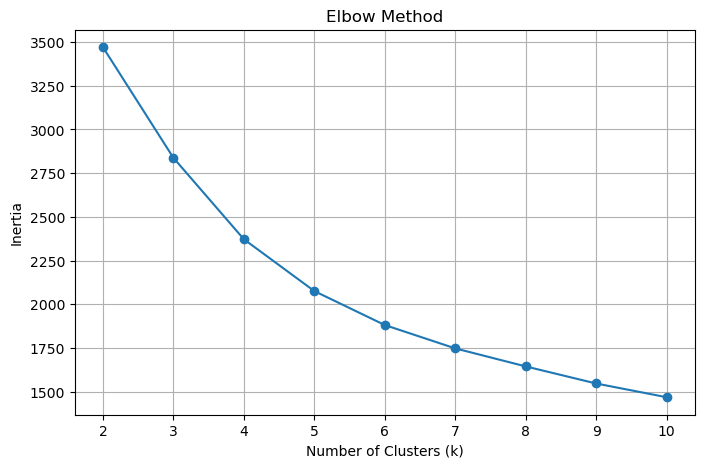

In [79]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

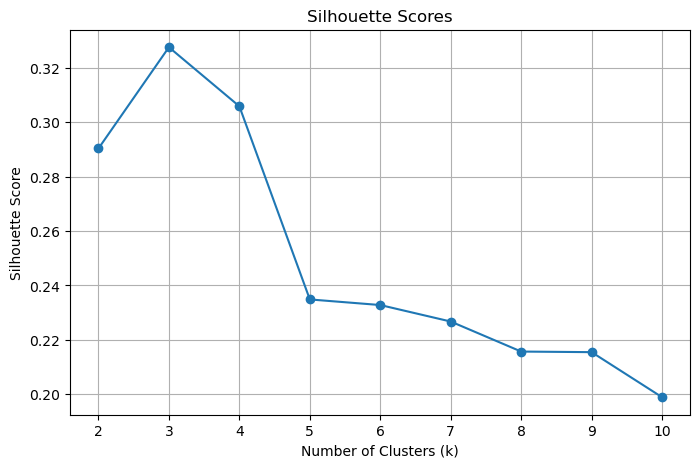

In [80]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")

plt.title("Silhouette Scores")

plt.grid(True)

plt.show()

In [81]:
results = pd.DataFrame({
    "Clusters": list(k_values),
    "Inertia": inertia,
    "Silhouette Score": silhouette_scores
})

display(results)

best_k = results.loc[
    results["Silhouette Score"].idxmax(),
    "Clusters"
]

print(f"Recommended number of clusters: {best_k}")

,Clusters,Inertia,Silhouette Score
0,2,3470.116303,0.290327
1,3,2837.691992,0.327536
2,4,2372.350778,0.305826
3,5,2075.988308,0.234868
4,6,1881.866222,0.232810
5,7,1748.347965,0.226748
6,8,1645.348220,0.215717
7,9,1547.685908,0.215496
8,10,1469.172297,0.198939


Recommended number of clusters: 3


In [82]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

eligible_players["cluster"] = cluster_labels

print("K-Means model trained successfully.")
print(f"Number of clusters: {best_k}")

K-Means model trained successfully.
Number of clusters: 3


In [83]:
cluster_counts = (
    eligible_players["cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_counts.columns = ["Cluster", "Players"]

display(cluster_counts)

,Cluster,Players
0,0,119
1,1,253
2,2,28


In [84]:
player_information["cluster"] = cluster_labels

display(player_information.head())

,player_name,club_name,position_name,minutes,market_value,cluster
0,Michael Keane,Everton,DEF,2588,€1.00m,1
1,Axel Tuanzebe,Burnley,DEF,1201,€1.00m,1
2,Lewis Dunk,Brighton & Hove Albion,DEF,2837,€1.50m,1
3,Justin Devenny,Crystal Palace,MID,785,€1.50m,1
4,Ross Barkley,Aston Villa,MID,844,€1.50m,0


In [85]:
cluster_summary = (
    eligible_players
    .groupby("cluster")[available_features]
    .mean()
    .round(2)
)

display(cluster_summary)

,goals_per_90,expected_goals_per_90,threat,assists_per_90,expected_assists_per_90,creativity,expected_goal_involvements_per_90,influence,tackles_per_90,recoveries_per_90,clearances_blocks_interceptions_per_90,defensive_contribution_per_90
cluster,,,,,,,,,,,,
0,0.28,0.29,497.22,0.20,0.14,434.99,0.43,442.06,1.17,3.47,1.56,6.06
1,0.05,0.07,152.11,0.09,0.07,223.46,0.14,374.36,1.90,3.99,4.59,8.41
2,0.00,0.00,1.46,0.01,0.00,11.09,0.00,593.26,0.03,8.03,1.25,0.00


In [86]:
for cluster in sorted(eligible_players["cluster"].unique()):

    print("=" * 60)
    print(f"Cluster {cluster}")

    sample = (
        eligible_players[
            eligible_players["cluster"] == cluster
        ][
            ["player_name", "club_name", "position_name"]
        ]
        .head(10)
    )

    display(sample)

Cluster 0


,player_name,club_name,position_name
15,Ross Barkley,Aston Villa,MID
20,Taiwo Awoniyi,Nottingham Forest,FWD
21,Emiliano Buendía,Aston Villa,MID
24,Brenden Aaronson,Leeds United,MID
26,Eli Junior Kroupi,AFC Bournemouth,FWD
31,John McGinn,Aston Villa,MID
33,Maxim De Cuyper,Brighton & Hove Albion,DEF
36,Harry Wilson,Fulham,MID
37,Jacob Murphy,Newcastle United,MID
42,Enzo Le Fée,Sunderland,MID


Cluster 1


,player_name,club_name,position_name
3,Michael Keane,Everton,DEF
7,Axel Tuanzebe,Burnley,DEF
11,Lewis Dunk,Brighton & Hove Albion,DEF
12,Justin Devenny,Crystal Palace,MID
16,Lyle Foster,Burnley,FWD
17,Lamare Bogarde,Aston Villa,DEF
19,Lewis Cook,AFC Bournemouth,MID
22,Konstantinos Mavropanos,West Ham United,DEF
23,Ryan Sessegnon,Fulham,MID
27,Rodrigo Gomes,Wolverhampton Wanderers,DEF


Cluster 2


,player_name,club_name,position_name
18,Sam Johnstone,Wolverhampton Wanderers,GKP
44,Jordan Pickford,Everton,GKP
67,Robert Sánchez,Chelsea FC,GKP
75,Caoimhín Kelleher,Brentford,GKP
77,Dean Henderson,Crystal Palace,GKP
120,Matz Sels,Nottingham Forest,GKP
154,Guglielmo Vicario,Tottenham Hotspur,GKP
159,Giorgi Mamardashvili,Liverpool FC,GKP
172,Bart Verbruggen,Brighton & Hove Albion,GKP
232,Nick Pope,Newcastle United,GKP


In [87]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

principal_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    principal_components,
    columns=["PC1", "PC2"],
    index=X_scaled.index
)

pca_df["cluster"] = cluster_labels

pca_df.head()

,PC1,PC2,cluster
3,-1.553304,0.055849,1
7,-2.351839,-0.680299,1
11,-1.655547,-0.555253,1
12,-0.159188,-0.242387,1
15,1.097119,-0.034031,0


In [88]:
explained_variance = pd.DataFrame({
    "Component": ["PC1", "PC2"],
    "Explained Variance": pca.explained_variance_ratio_
})

explained_variance["Cumulative Variance"] = (
    explained_variance["Explained Variance"].cumsum()
)

display(explained_variance.round(4))

,Component,Explained Variance,Cumulative Variance
0,PC1,0.3868,0.3868
1,PC2,0.1865,0.5733


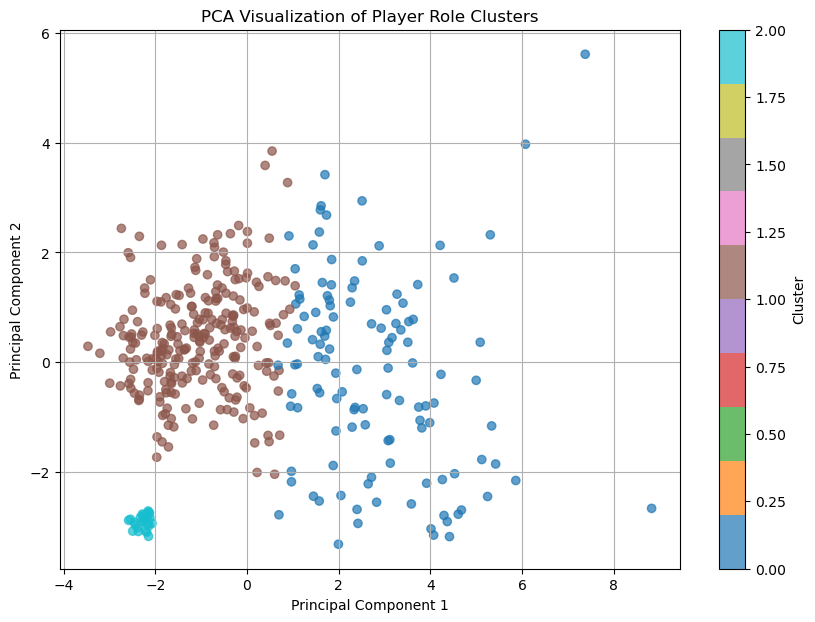

In [90]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["cluster"],
    cmap="tab10",
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Player Role Clusters")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()

In [91]:
pca_players = player_information.copy()

pca_players["PC1"] = pca_df["PC1"].values
pca_players["PC2"] = pca_df["PC2"].values
pca_players["cluster"] = cluster_labels

display(
    pca_players[
        [
            "player_name",
            "club_name",
            "position_name",
            "cluster",
            "PC1",
            "PC2"
        ]
    ].head()
)

,player_name,club_name,position_name,cluster,PC1,PC2
0,Michael Keane,Everton,DEF,1,-1.553304,0.055849
1,Axel Tuanzebe,Burnley,DEF,1,-2.351839,-0.680299
2,Lewis Dunk,Brighton & Hove Albion,DEF,1,-1.655547,-0.555253
3,Justin Devenny,Crystal Palace,MID,1,-0.159188,-0.242387
4,Ross Barkley,Aston Villa,MID,0,1.097119,-0.034031


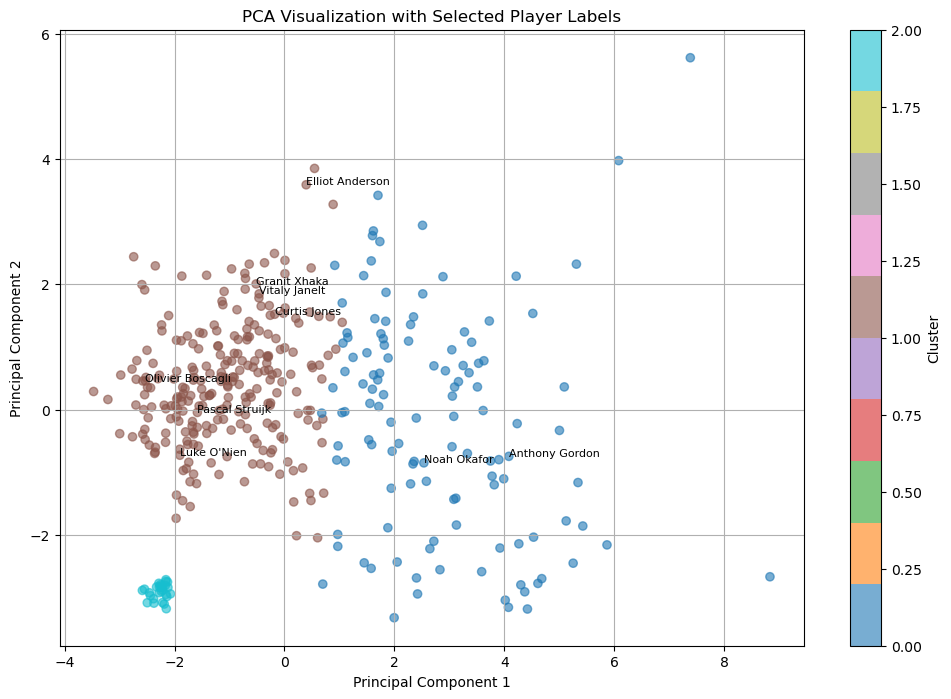

In [92]:
top_players = (
    eligible_players
    .sort_values("minutes", ascending=False)
    .groupby("cluster")
    .head(3)
)

top_player_indices = top_players.index

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["cluster"],
    cmap="tab10",
    alpha=0.6
)

for index in top_player_indices:
    if index in pca_players.index:
        plt.annotate(
            pca_players.loc[index, "player_name"],
            (
                pca_players.loc[index, "PC1"],
                pca_players.loc[index, "PC2"]
            ),
            fontsize=8
        )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization with Selected Player Labels")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()

In [93]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=X_scaled.columns
)

display(
    pca_loadings
    .sort_values("PC1", key=abs, ascending=False)
    .round(3)
)

,PC1,PC2
expected_goal_involvements_per_90,0.446,-0.002
expected_goals_per_90,0.402,-0.188
threat,0.396,-0.018
goals_per_90,0.385,-0.169
expected_assists_per_90,0.278,0.376
creativity,0.266,0.397
clearances_blocks_interceptions_per_90,-0.265,0.161
assists_per_90,0.264,0.276
recoveries_per_90,-0.158,0.035
tackles_per_90,-0.092,0.506


In [96]:
cluster_positions = pd.crosstab(
    eligible_players["cluster"],
    eligible_players["position_name"]
)

display(cluster_positions)

position_name,DEF,FWD,GKP,MID
cluster,,,,
0,4,38,0,77
1,143,6,0,104
2,0,0,28,0


In [100]:
eligible_players["market_value_numeric"] = pd.to_numeric(
    eligible_players["market_value"]
    .astype(str)
    .str.replace("€", "", regex=False)
    .str.replace("m", "", regex=False)
    .str.replace(",", "", regex=False),
    errors="coerce"
)

In [101]:
cluster_market_value = (
    eligible_players
    .groupby("cluster")["market_value_numeric"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(cluster_market_value)

,count,mean,median,min,max
cluster,,,,,
0,89,37.42,25.0,1.5,180.0
1,144,23.30,20.0,1.0,100.0
2,12,12.44,13.5,1.8,25.0


In [103]:
for cluster in sorted(eligible_players["cluster"].unique()):

    print("=" * 80)
    print(f"CLUSTER {cluster}")

    display(
        eligible_players[
            eligible_players["cluster"] == cluster
        ]
        .sort_values(
            "market_value_numeric",
            ascending=False
        )[[
            "player_name",
            "club_name",
            "position_name",
            "market_value"
        ]]
        .head(20)
    )

CLUSTER 0


,player_name,club_name,position_name,market_value
101,Erling Haaland,Manchester City,FWD,€180.00m
79,Bukayo Saka,Arsenal FC,MID,€150.00m
66,Florian Wirtz,Liverpool FC,MID,€140.00m
56,Cole Palmer,Chelsea FC,MID,€120.00m
57,Alexander Isak,Liverpool FC,FWD,€120.00m
43,Declan Rice,Arsenal FC,MID,€110.00m
360,Phil Foden,Manchester City,MID,€85.00m
355,Martin Ødegaard,Arsenal FC,MID,€80.00m
354,Dominik Szoboszlai,Liverpool FC,MID,€80.00m
335,Bruno Guimarães,Newcastle United,MID,€75.00m


CLUSTER 1


,player_name,club_name,position_name,market_value
38,Rodri,Manchester City,MID,€100.00m
366,Alexis Mac Allister,Liverpool FC,MID,€90.00m
353,Moisés Caicedo,Chelsea FC,MID,€80.00m
337,Ryan Gravenberch,Liverpool FC,MID,€75.00m
336,William Saliba,Arsenal FC,DEF,€75.00m
328,Gabriel Magalhães,Arsenal FC,DEF,€70.00m
316,Josko Gvardiol,Manchester City,DEF,€65.00m
308,Rúben Dias,Manchester City,DEF,€60.00m
295,Martín Zubimendi,Arsenal FC,MID,€55.00m
294,Sandro Tonali,Newcastle United,MID,€55.00m


CLUSTER 2


,player_name,club_name,position_name,market_value
154,Guglielmo Vicario,Tottenham Hotspur,GKP,€25.00m
159,Giorgi Mamardashvili,Liverpool FC,GKP,€25.00m
172,Bart Verbruggen,Brighton & Hove Albion,GKP,€25.00m
67,Robert Sánchez,Chelsea FC,GKP,€15.00m
75,Caoimhín Kelleher,Brentford,GKP,€15.00m
77,Dean Henderson,Crystal Palace,GKP,€15.00m
44,Jordan Pickford,Everton,GKP,€12.00m
270,Bernd Leno,Fulham,GKP,€5.00m
232,Nick Pope,Newcastle United,GKP,€4.00m
234,Alphonse Areola,West Ham United,GKP,€4.00m


CLUSTER 0


,player_name,club_name,position_name,market_value
101,Erling Haaland,Manchester City,FWD,€180.00m
79,Bukayo Saka,Arsenal FC,MID,€150.00m
66,Florian Wirtz,Liverpool FC,MID,€140.00m
56,Cole Palmer,Chelsea FC,MID,€120.00m
57,Alexander Isak,Liverpool FC,FWD,€120.00m
43,Declan Rice,Arsenal FC,MID,€110.00m
360,Phil Foden,Manchester City,MID,€85.00m
355,Martin Ødegaard,Arsenal FC,MID,€80.00m
354,Dominik Szoboszlai,Liverpool FC,MID,€80.00m
335,Bruno Guimarães,Newcastle United,MID,€75.00m


CLUSTER 1


,player_name,club_name,position_name,market_value
38,Rodri,Manchester City,MID,€100.00m
366,Alexis Mac Allister,Liverpool FC,MID,€90.00m
353,Moisés Caicedo,Chelsea FC,MID,€80.00m
337,Ryan Gravenberch,Liverpool FC,MID,€75.00m
336,William Saliba,Arsenal FC,DEF,€75.00m
328,Gabriel Magalhães,Arsenal FC,DEF,€70.00m
316,Josko Gvardiol,Manchester City,DEF,€65.00m
308,Rúben Dias,Manchester City,DEF,€60.00m
295,Martín Zubimendi,Arsenal FC,MID,€55.00m
294,Sandro Tonali,Newcastle United,MID,€55.00m


CLUSTER 2


,player_name,club_name,position_name,market_value
154,Guglielmo Vicario,Tottenham Hotspur,GKP,€25.00m
159,Giorgi Mamardashvili,Liverpool FC,GKP,€25.00m
172,Bart Verbruggen,Brighton & Hove Albion,GKP,€25.00m
67,Robert Sánchez,Chelsea FC,GKP,€15.00m
75,Caoimhín Kelleher,Brentford,GKP,€15.00m
77,Dean Henderson,Crystal Palace,GKP,€15.00m
44,Jordan Pickford,Everton,GKP,€12.00m
270,Bernd Leno,Fulham,GKP,€5.00m
232,Nick Pope,Newcastle United,GKP,€4.00m
234,Alphonse Areola,West Ham United,GKP,€4.00m


In [105]:
cluster_names = {
    0: "Attacking Creators & Finishers",
    1: "Defensive Core Players",
    2: "Goalkeepers"
}

In [106]:
cluster_names = {
    0: "Attacking Creators & Finishers",
    1: "Defensive Core Players",
    2: "Goalkeepers"
}

eligible_players["role"] = eligible_players["cluster"].map(cluster_names)

In [107]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(X_scaled)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=eligible_players.index,
    columns=eligible_players.index
)

similarity_df.head()

,3,7,11,12,15,16,17,18,19,20,...,505,507,509,511,512,515,516,520,524,538
3,1.000000,0.725011,0.841597,-0.257024,-0.559303,-0.232022,0.034617,-0.126617,0.290782,-0.367356,...,-0.143685,0.279008,0.736958,0.108815,-0.191877,-0.228267,0.399001,0.485957,-0.209332,0.563457
7,0.725011,1.000000,0.725992,0.039565,-0.421360,0.097109,0.549026,0.177671,0.443082,-0.402913,...,0.355200,0.609884,0.940582,0.517251,0.212315,0.370059,0.862870,0.918262,0.252209,0.958958
11,0.841597,0.725992,1.000000,-0.303536,-0.721869,-0.213279,0.320826,0.379644,0.270156,-0.604303,...,0.313638,0.379698,0.616912,0.030805,0.310478,0.010748,0.529174,0.518155,0.288472,0.612674
12,-0.257024,0.039565,-0.303536,1.000000,0.177589,0.347840,0.428860,-0.095297,0.226469,0.156770,...,-0.001995,0.462718,0.006970,0.370668,-0.039280,0.581095,0.292523,0.282336,-0.020735,0.135301
15,-0.559303,-0.421360,-0.721869,0.177589,1.000000,0.278012,-0.302968,-0.111655,-0.079201,0.738648,...,-0.161229,-0.384345,-0.384906,-0.070290,-0.068985,-0.081310,-0.410935,-0.403130,-0.092169,-0.399189


In [112]:
def recommend_replacements(player_name, top_n=5, same_position=True):
    matches = eligible_players[
        eligible_players["player_name"].str.lower() == player_name.lower()
    ]

    if matches.empty:
        return f"Player '{player_name}' was not found."

    player_index = matches.index[0]
    player_cluster = eligible_players.loc[player_index, "cluster"]
    player_position = eligible_players.loc[player_index, "position_name"]

    candidate_mask = (
        (eligible_players["cluster"] == player_cluster) &
        (eligible_players.index != player_index)
    )

    if same_position:
        candidate_mask &= (
            eligible_players["position_name"] == player_position
        )

    candidates = eligible_players[candidate_mask].copy()

    candidates["similarity_score"] = (
        similarity_df.loc[player_index, candidates.index].values
    )

    results = (
        candidates
        .sort_values("similarity_score", ascending=False)
        .head(top_n)
        .copy()
    )

    results["similarity_percent"] = (
        results["similarity_score"] * 100
    ).round(1)

    return results[
        [
            "player_name",
            "club_name",
            "position_name",
            "role",
            "similarity_percent",
            "market_value"
        ]
    ].reset_index(drop=True)

In [116]:
recommend_replacements(
    "Erling Haaland",
    top_n=10,
    same_position=True
)

,player_name,club_name,position_name,role,similarity_percent,market_value
0,Richarlison,Tottenham Hotspur,FWD,Attacking Creators & Finishers,97.5,€16.00m
1,João Pedro,Chelsea FC,FWD,Attacking Creators & Finishers,97.3,€45.00m
2,Igor Thiago,Brentford,FWD,Attacking Creators & Finishers,96.7,€12.00m
3,Ollie Watkins,Aston Villa,FWD,Attacking Creators & Finishers,96.2,€35.00m
4,Dominic Calvert Lewin,Leeds United,FWD,Attacking Creators & Finishers,94.6,NaN
5,Hugo Ekitiké,Liverpool FC,FWD,Attacking Creators & Finishers,94.6,NaN
6,Danny Welbeck,Brighton & Hove Albion,FWD,Attacking Creators & Finishers,94.3,€900k
7,Raúl Raúl,Fulham,FWD,Attacking Creators & Finishers,93.4,NaN
8,Viktor Gyokeres,Arsenal FC,FWD,Attacking Creators & Finishers,92.1,NaN
9,Benjamin Šeško,Manchester United,FWD,Attacking Creators & Finishers,91.3,NaN


In [114]:
recommend_replacements("Rodri", top_n=10)

,player_name,club_name,position_name,role,similarity_percent,market_value
0,Curtis Jones,Liverpool FC,MID,Defensive Core Players,89.1,€40.00m
1,Douglas Luiz Douglas Luiz,Aston Villa,MID,Defensive Core Players,87.4,NaN
2,Tanaka Tanaka,Leeds United,MID,Defensive Core Players,84.2,NaN
3,Moisés Caicedo,Chelsea FC,MID,Defensive Core Players,84.2,€80.00m
4,Daichi Kamada,Crystal Palace,MID,Defensive Core Players,83.6,€7.50m
5,João Victor J.Gomes,Wolverhampton Wanderers,MID,Defensive Core Players,82.8,NaN
6,Alex Scott,AFC Bournemouth,MID,Defensive Core Players,78.1,€15.00m
7,Ibrahim Sangaré,Nottingham Forest,MID,Defensive Core Players,78.0,€20.00m
8,Idrissa Gana Gana,Everton,MID,Defensive Core Players,77.4,NaN
9,André André,Wolverhampton Wanderers,MID,Defensive Core Players,76.9,NaN


In [115]:
recommend_replacements("William Saliba", top_n=10)

,player_name,club_name,position_name,role,similarity_percent,market_value
0,Rúben Dias,Manchester City,DEF,Defensive Core Players,92.8,€60.00m
1,Ezri Konsa,Aston Villa,DEF,Defensive Core Players,91.8,€30.00m
2,Lewis Dunk,Brighton & Hove Albion,DEF,Defensive Core Players,91.0,€1.50m
3,Nikola Milenković,Nottingham Forest,DEF,Defensive Core Players,89.9,€30.00m
4,Ibrahima Konaté,Liverpool FC,DEF,Defensive Core Players,89.3,€55.00m
5,Kyle Walker,Burnley,DEF,Defensive Core Players,88.7,€600k
6,Murillo Murillo,Nottingham Forest,DEF,Defensive Core Players,87.2,NaN
7,Vitalii Mykolenko,Everton,DEF,Defensive Core Players,87.1,NaN
8,Maxime Estève,Burnley,DEF,Defensive Core Players,85.3,€14.00m
9,Trevoh Chalobah,Chelsea FC,DEF,Defensive Core Players,85.2,€20.00m


In [117]:
def recommend_replacements(
    player_name,
    top_n=5,
    same_position=True,
    max_market_value=None
):
    matches = eligible_players[
        eligible_players["player_name"].str.lower() == player_name.lower()
    ]

    if matches.empty:
        return f"Player '{player_name}' was not found."

    player_index = matches.index[0]
    player_cluster = eligible_players.loc[player_index, "cluster"]
    player_position = eligible_players.loc[player_index, "position_name"]

    candidate_mask = (
        (eligible_players["cluster"] == player_cluster) &
        (eligible_players.index != player_index)
    )

    if same_position:
        candidate_mask &= (
            eligible_players["position_name"] == player_position
        )

    if max_market_value is not None:
        candidate_mask &= (
            eligible_players["market_value_numeric"] <= max_market_value
        )

    candidates = eligible_players[candidate_mask].copy()

    if candidates.empty:
        return "No players matched the selected filters."

    candidates["similarity_score"] = (
        similarity_df.loc[player_index, candidates.index].values
    )

    results = (
        candidates
        .sort_values("similarity_score", ascending=False)
        .head(top_n)
        .copy()
    )

    results["similarity_percent"] = (
        results["similarity_score"] * 100
    ).round(1)

    return results[
        [
            "player_name",
            "club_name",
            "position_name",
            "role",
            "similarity_percent",
            "market_value"
        ]
    ].reset_index(drop=True)

In [118]:
recommend_replacements(
    "Erling Haaland",
    top_n=10,
    same_position=True,
    max_market_value=60
)

,player_name,club_name,position_name,role,similarity_percent,market_value
0,Richarlison,Tottenham Hotspur,FWD,Attacking Creators & Finishers,97.5,€16.00m
1,João Pedro,Chelsea FC,FWD,Attacking Creators & Finishers,97.3,€45.00m
2,Igor Thiago,Brentford,FWD,Attacking Creators & Finishers,96.7,€12.00m
3,Ollie Watkins,Aston Villa,FWD,Attacking Creators & Finishers,96.2,€35.00m
4,Jean-Philippe Mateta,Crystal Palace,FWD,Attacking Creators & Finishers,90.9,€25.00m
5,Eli Junior Kroupi,AFC Bournemouth,FWD,Attacking Creators & Finishers,84.7,€10.00m
6,Zian Flemming,Burnley,FWD,Attacking Creators & Finishers,81.7,€2.00m
7,Evanilson,AFC Bournemouth,FWD,Attacking Creators & Finishers,80.6,€30.00m
8,Wilson Isidor,Sunderland,FWD,Attacking Creators & Finishers,71.4,€7.00m
9,William Osula,Newcastle United,FWD,Attacking Creators & Finishers,71.1,€2.50m


In [119]:
def recommend_replacements(
    player_name,
    top_n=5,
    same_position=True,
    max_market_value=None
):
    matches = eligible_players[
        eligible_players["player_name"].str.lower() == player_name.lower()
    ]

    if matches.empty:
        return f"Player '{player_name}' was not found."

    player_index = matches.index[0]
    selected_player = eligible_players.loc[player_index]

    player_cluster = selected_player["cluster"]
    player_position = selected_player["position_name"]
    player_value = selected_player["market_value_numeric"]

    candidate_mask = (
        (eligible_players["cluster"] == player_cluster) &
        (eligible_players.index != player_index)
    )

    if same_position:
        candidate_mask &= (
            eligible_players["position_name"] == player_position
        )

    if max_market_value is not None:
        candidate_mask &= (
            eligible_players["market_value_numeric"] <= max_market_value
        )

    candidates = eligible_players[candidate_mask].copy()

    if candidates.empty:
        return "No players matched the selected filters."

    candidates["similarity_score"] = (
        similarity_df.loc[player_index, candidates.index].values
    )

    candidates["similarity_percent"] = (
        candidates["similarity_score"] * 100
    ).round(1)

    candidates["value_difference"] = (
        candidates["market_value_numeric"] - player_value
    ).round(2)

    candidates["value_difference_display"] = candidates[
        "value_difference"
    ].apply(
        lambda value: (
            f"+€{value:.2f}m"
            if value > 0
            else f"-€{abs(value):.2f}m"
            if value < 0
            else "€0.00m"
        )
        if pd.notna(value)
        else "Unknown"
    )

    results = (
        candidates
        .sort_values("similarity_score", ascending=False)
        .head(top_n)
        .copy()
    )

    selected_player_summary = pd.DataFrame({
        "Player": [selected_player["player_name"]],
        "Club": [selected_player["club_name"]],
        "Position": [selected_player["position_name"]],
        "Role": [selected_player["role"]],
        "Market Value": [selected_player["market_value"]]
    })

    recommendation_table = results[
        [
            "player_name",
            "club_name",
            "position_name",
            "role",
            "similarity_percent",
            "market_value",
            "value_difference_display"
        ]
    ].copy()

    recommendation_table.columns = [
        "Player",
        "Club",
        "Position",
        "Role",
        "Similarity (%)",
        "Market Value",
        "Value Difference"
    ]

    return selected_player_summary, recommendation_table.reset_index(drop=True)

In [120]:
selected_player, recommendations = recommend_replacements(
    "Erling Haaland",
    top_n=10
)

print("SELECTED PLAYER")
display(selected_player)

print("RECOMMENDED REPLACEMENTS")
display(recommendations)

SELECTED PLAYER


,Player,Club,Position,Role,Market Value
0,Erling Haaland,Manchester City,FWD,Attacking Creators & Finishers,€180.00m


RECOMMENDED REPLACEMENTS


,Player,Club,Position,Role,Similarity (%),Market Value,Value Difference
0,Richarlison,Tottenham Hotspur,FWD,Attacking Creators & Finishers,97.5,€16.00m,-€164.00m
1,João Pedro,Chelsea FC,FWD,Attacking Creators & Finishers,97.3,€45.00m,-€135.00m
2,Igor Thiago,Brentford,FWD,Attacking Creators & Finishers,96.7,€12.00m,-€168.00m
3,Ollie Watkins,Aston Villa,FWD,Attacking Creators & Finishers,96.2,€35.00m,-€145.00m
4,Dominic Calvert Lewin,Leeds United,FWD,Attacking Creators & Finishers,94.6,NaN,Unknown
5,Hugo Ekitiké,Liverpool FC,FWD,Attacking Creators & Finishers,94.6,NaN,Unknown
6,Danny Welbeck,Brighton & Hove Albion,FWD,Attacking Creators & Finishers,94.3,€900k,Unknown
7,Raúl Raúl,Fulham,FWD,Attacking Creators & Finishers,93.4,NaN,Unknown
8,Viktor Gyokeres,Arsenal FC,FWD,Attacking Creators & Finishers,92.1,NaN,Unknown
9,Benjamin Šeško,Manchester United,FWD,Attacking Creators & Finishers,91.3,NaN,Unknown


In [121]:
selected_player, recommendations = recommend_replacements(
    "Erling Haaland",
    top_n=10,
    same_position=True,
    max_market_value=40
)

print("SELECTED PLAYER")
display(selected_player)

print("RECOMMENDED REPLACEMENTS UNDER €40M")
display(recommendations)

SELECTED PLAYER


,Player,Club,Position,Role,Market Value
0,Erling Haaland,Manchester City,FWD,Attacking Creators & Finishers,€180.00m


RECOMMENDED REPLACEMENTS UNDER €40M


,Player,Club,Position,Role,Similarity (%),Market Value,Value Difference
0,Richarlison,Tottenham Hotspur,FWD,Attacking Creators & Finishers,97.5,€16.00m,-€164.00m
1,Igor Thiago,Brentford,FWD,Attacking Creators & Finishers,96.7,€12.00m,-€168.00m
2,Ollie Watkins,Aston Villa,FWD,Attacking Creators & Finishers,96.2,€35.00m,-€145.00m
3,Jean-Philippe Mateta,Crystal Palace,FWD,Attacking Creators & Finishers,90.9,€25.00m,-€155.00m
4,Eli Junior Kroupi,AFC Bournemouth,FWD,Attacking Creators & Finishers,84.7,€10.00m,-€170.00m
5,Zian Flemming,Burnley,FWD,Attacking Creators & Finishers,81.7,€2.00m,-€178.00m
6,Evanilson,AFC Bournemouth,FWD,Attacking Creators & Finishers,80.6,€30.00m,-€150.00m
7,Wilson Isidor,Sunderland,FWD,Attacking Creators & Finishers,71.4,€7.00m,-€173.00m
8,William Osula,Newcastle United,FWD,Attacking Creators & Finishers,71.1,€2.50m,-€177.50m
9,Taiwo Awoniyi,Nottingham Forest,FWD,Attacking Creators & Finishers,70.3,€10.00m,-€170.00m


SELECTED PLAYER


NameError: name 'selected_player_summary' is not defined

In [124]:
recommend_replacements("Mohamed Salah")

(          Player          Club Position                            Role  \
 0  Mohamed Salah  Liverpool FC      MID  Attacking Creators & Finishers   
 
   Market Value  
 0      €45.00m  ,
              Player               Club Position  \
 0  Leandro Trossard         Arsenal FC      MID   
 1        Cody Gakpo       Liverpool FC      MID   
 2       Bukayo Saka         Arsenal FC      MID   
 3    Dango Ouattara          Brentford      MID   
 4      Bryan Mbeumo  Manchester United      MID   
 
                              Role  Similarity (%) Market Value  \
 0  Attacking Creators & Finishers            97.9      €18.00m   
 1  Attacking Creators & Finishers            93.7      €65.00m   
 2  Attacking Creators & Finishers            93.3     €150.00m   
 3  Attacking Creators & Finishers            92.3      €25.00m   
 4  Attacking Creators & Finishers            92.3      €50.00m   
 
   Value Difference  
 0         -€27.00m  
 1         +€20.00m  
 2        +€105.00m  
 3 

In [125]:
recommend_replacements("Virgil van Dijk")

(            Player          Club Position                    Role Market Value
 0  Virgil van Dijk  Liverpool FC      DEF  Defensive Core Players      €20.00m,
                Player                    Club Position  \
 0     James Tarkowski                 Everton      DEF   
 1  Jan Paul van Hecke  Brighton & Hove Albion      DEF   
 2        Malick Thiaw        Newcastle United      DEF   
 3          Marc Guehi         Manchester City      DEF   
 4   Gabriel Magalhães              Arsenal FC      DEF   
 
                      Role  Similarity (%) Market Value Value Difference  
 0  Defensive Core Players            94.6       €4.50m         -€15.50m  
 1  Defensive Core Players            94.2      €28.00m          +€8.00m  
 2  Defensive Core Players            93.3          NaN          Unknown  
 3  Defensive Core Players            90.8          NaN          Unknown  
 4  Defensive Core Players            88.5      €70.00m         +€50.00m  )

In [127]:
from IPython.display import display, Markdown

def recommend_player_replacements(
    player_name,
    top_n=5,
    same_position=True,
    max_market_value=None
):

    matches = eligible_players[
        eligible_players["player_name"].str.lower() == player_name.lower()
    ]

    if matches.empty:
        print(f"Player '{player_name}' was not found.")
        return

    player_index = matches.index[0]
    selected_player = eligible_players.loc[player_index]

    player_cluster = selected_player["cluster"]
    player_position = selected_player["position_name"]
    player_value = selected_player["market_value_numeric"]

    candidate_mask = (
        (eligible_players["cluster"] == player_cluster) &
        (eligible_players.index != player_index)
    )

    if same_position:
        candidate_mask &= (
            eligible_players["position_name"] == player_position
        )

    if max_market_value is not None:
        candidate_mask &= (
            eligible_players["market_value_numeric"] <= max_market_value
        )

    candidates = eligible_players[candidate_mask].copy()

    if candidates.empty:
        print("No players matched the selected filters.")
        return

    candidates["similarity_score"] = (
        similarity_df.loc[player_index, candidates.index].values
    )

    candidates["similarity_percent"] = (
        candidates["similarity_score"] * 100
    ).round(1)

    candidates["value_difference"] = (
        candidates["market_value_numeric"] - player_value
    ).round(2)

    candidates["value_difference_display"] = candidates[
        "value_difference"
    ].apply(
        lambda value:
            f"+€{value:.2f}m" if pd.notna(value) and value > 0
            else f"-€{abs(value):.2f}m" if pd.notna(value) and value < 0
            else "€0.00m" if pd.notna(value)
            else "Unknown"
    )

    results = (
        candidates
        .sort_values("similarity_score", ascending=False)
        .head(top_n)
        .copy()
    )

    selected_player_summary = pd.DataFrame({
        "Player": [selected_player["player_name"]],
        "Club": [selected_player["club_name"]],
        "Position": [selected_player["position_name"]],
        "Role": [selected_player["role"]],
        "Market Value": [selected_player["market_value"]]
    })

    recommendation_table = results[
        [
            "player_name",
            "club_name",
            "position_name",
            "role",
            "similarity_percent",
            "market_value",
            "value_difference_display"
        ]
    ].copy()

    recommendation_table.columns = [
        "Player",
        "Club",
        "Position",
        "Role",
        "Similarity (%)",
        "Market Value",
        "Value Difference"
    ]

    display(Markdown("## Selected Player"))
    display(selected_player_summary)

    display(Markdown("## Recommended Replacements"))
    display(recommendation_table.reset_index(drop=True))

In [128]:
recommend_player_replacements("Erling Haaland")

## Selected Player

,Player,Club,Position,Role,Market Value
0,Erling Haaland,Manchester City,FWD,Attacking Creators & Finishers,€180.00m


## Recommended Replacements

,Player,Club,Position,Role,Similarity (%),Market Value,Value Difference
0,Richarlison,Tottenham Hotspur,FWD,Attacking Creators & Finishers,97.5,€16.00m,-€164.00m
1,João Pedro,Chelsea FC,FWD,Attacking Creators & Finishers,97.3,€45.00m,-€135.00m
2,Igor Thiago,Brentford,FWD,Attacking Creators & Finishers,96.7,€12.00m,-€168.00m
3,Ollie Watkins,Aston Villa,FWD,Attacking Creators & Finishers,96.2,€35.00m,-€145.00m
4,Dominic Calvert Lewin,Leeds United,FWD,Attacking Creators & Finishers,94.6,NaN,Unknown


In [129]:
recommend_player_replacements("Rodri")

## Selected Player

,Player,Club,Position,Role,Market Value
0,Rodri,Manchester City,MID,Defensive Core Players,€100.00m


## Recommended Replacements

,Player,Club,Position,Role,Similarity (%),Market Value,Value Difference
0,Curtis Jones,Liverpool FC,MID,Defensive Core Players,89.1,€40.00m,-€60.00m
1,Douglas Luiz Douglas Luiz,Aston Villa,MID,Defensive Core Players,87.4,NaN,Unknown
2,Tanaka Tanaka,Leeds United,MID,Defensive Core Players,84.2,NaN,Unknown
3,Moisés Caicedo,Chelsea FC,MID,Defensive Core Players,84.2,€80.00m,-€20.00m
4,Daichi Kamada,Crystal Palace,MID,Defensive Core Players,83.6,€7.50m,-€92.50m


In [130]:
recommend_player_replacements(
    "Erling Haaland",
    top_n=10,
    max_market_value=40
)

## Selected Player

,Player,Club,Position,Role,Market Value
0,Erling Haaland,Manchester City,FWD,Attacking Creators & Finishers,€180.00m


## Recommended Replacements

,Player,Club,Position,Role,Similarity (%),Market Value,Value Difference
0,Richarlison,Tottenham Hotspur,FWD,Attacking Creators & Finishers,97.5,€16.00m,-€164.00m
1,Igor Thiago,Brentford,FWD,Attacking Creators & Finishers,96.7,€12.00m,-€168.00m
2,Ollie Watkins,Aston Villa,FWD,Attacking Creators & Finishers,96.2,€35.00m,-€145.00m
3,Jean-Philippe Mateta,Crystal Palace,FWD,Attacking Creators & Finishers,90.9,€25.00m,-€155.00m
4,Eli Junior Kroupi,AFC Bournemouth,FWD,Attacking Creators & Finishers,84.7,€10.00m,-€170.00m
5,Zian Flemming,Burnley,FWD,Attacking Creators & Finishers,81.7,€2.00m,-€178.00m
6,Evanilson,AFC Bournemouth,FWD,Attacking Creators & Finishers,80.6,€30.00m,-€150.00m
7,Wilson Isidor,Sunderland,FWD,Attacking Creators & Finishers,71.4,€7.00m,-€173.00m
8,William Osula,Newcastle United,FWD,Attacking Creators & Finishers,71.1,€2.50m,-€177.50m
9,Taiwo Awoniyi,Nottingham Forest,FWD,Attacking Creators & Finishers,70.3,€10.00m,-€170.00m


In [131]:
recommend_player_replacements("Bukayo Saka", top_n=5)

## Selected Player

,Player,Club,Position,Role,Market Value
0,Bukayo Saka,Arsenal FC,MID,Attacking Creators & Finishers,€150.00m


## Recommended Replacements

,Player,Club,Position,Role,Similarity (%),Market Value,Value Difference
0,Jérémy Doku,Manchester City,MID,Attacking Creators & Finishers,95.6,€45.00m,-€105.00m
1,Leandro Trossard,Arsenal FC,MID,Attacking Creators & Finishers,93.8,€18.00m,-€132.00m
2,Mohamed Salah,Liverpool FC,MID,Attacking Creators & Finishers,93.3,€45.00m,-€105.00m
3,Phil Foden,Manchester City,MID,Attacking Creators & Finishers,93.0,€85.00m,-€65.00m
4,Rayan Cherki,Manchester City,MID,Attacking Creators & Finishers,93.0,€42.00m,-€108.00m


In [132]:
def compare_players(player_one, player_two):
    player_one_match = eligible_players[
        eligible_players["player_name"].str.lower() == player_one.lower()
    ]

    player_two_match = eligible_players[
        eligible_players["player_name"].str.lower() == player_two.lower()
    ]

    if player_one_match.empty or player_two_match.empty:
        print("One or both players were not found.")
        return

    player_one_data = player_one_match.iloc[0]
    player_two_data = player_two_match.iloc[0]

    comparison_features = [
        feature for feature in [
            "goals_per_90",
            "assists_per_90",
            "expected_goals_per_90",
            "expected_assists_per_90",
            "tackles_per_90",
            "recoveries_per_90",
            "defensive_contribution_per_90"
        ]
        if feature in eligible_players.columns
    ]

    comparison = pd.DataFrame({
        "Statistic": comparison_features,
        player_one_data["player_name"]: [
            player_one_data[feature] for feature in comparison_features
        ],
        player_two_data["player_name"]: [
            player_two_data[feature] for feature in comparison_features
        ]
    })

    display(comparison.round(2))

    comparison.set_index("Statistic").plot(
        kind="bar",
        figsize=(12, 6)
    )

    plt.title(
        f"{player_one_data['player_name']} vs "
        f"{player_two_data['player_name']}"
    )
    plt.ylabel("Performance Value")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

,Statistic,Erling Haaland,Ollie Watkins
0,goals_per_90,0.82,0.51
1,assists_per_90,0.24,0.13
2,expected_goals_per_90,0.78,0.49
3,expected_assists_per_90,0.08,0.04
4,tackles_per_90,0.46,0.70
5,recoveries_per_90,1.25,1.56
6,defensive_contribution_per_90,3.17,2.99


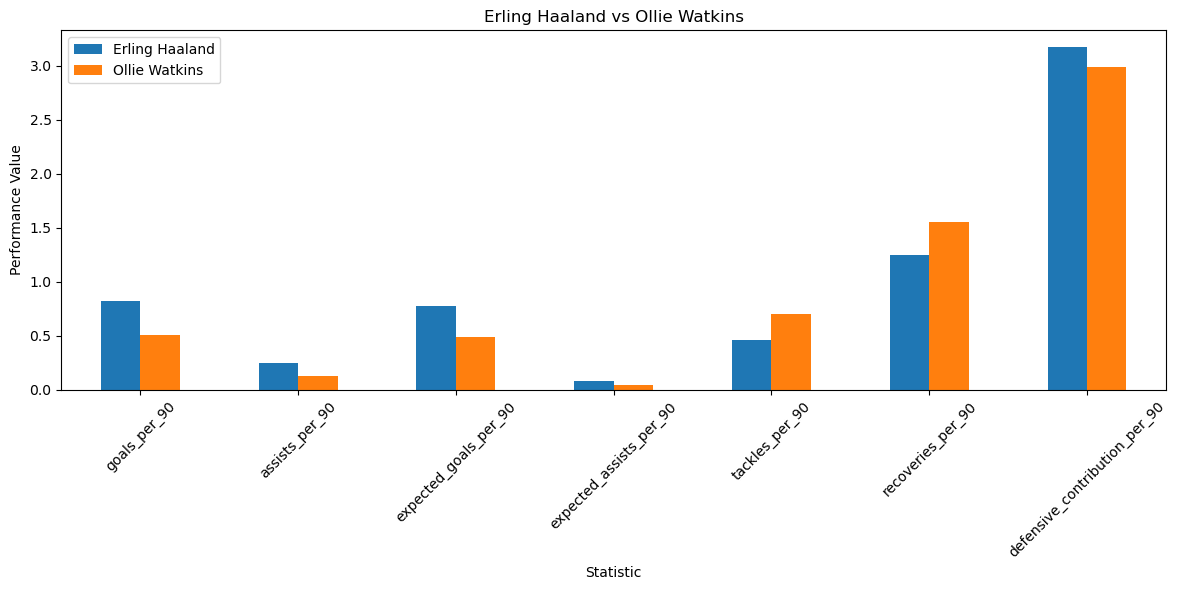

In [133]:
compare_players("Erling Haaland", "Ollie Watkins")

In [134]:
export_columns = [
    "player_name",
    "club_name",
    "position_name",
    "role",
    "cluster",
    "market_value",
    "market_value_numeric"
] + available_features

streamlit_data = eligible_players[
    [column for column in export_columns if column in eligible_players.columns]
].copy()

streamlit_data.to_csv(
    "player_replacement_data.csv",
    index=False
)

print(streamlit_data.shape)
streamlit_data.head()

(400, 19)


,player_name,club_name,position_name,role,cluster,market_value,market_value_numeric,goals_per_90,expected_goals_per_90,threat,assists_per_90,expected_assists_per_90,creativity,expected_goal_involvements_per_90,influence,tackles_per_90,recoveries_per_90,clearances_blocks_interceptions_per_90,defensive_contribution_per_90
3,Michael Keane,Everton,DEF,Defensive Core Players,1,€1.00m,1.0,0.104328,0.08,299.0,0.034776,0.02,47.4,0.10,770.4,1.286708,3.025502,9.215611,10.50
7,Axel Tuanzebe,Burnley,DEF,Defensive Core Players,1,€1.00m,1.0,0.074938,0.05,52.0,0.000000,0.01,11.1,0.06,276.4,1.049126,2.997502,7.943381,8.99
11,Lewis Dunk,Brighton & Hove Albion,DEF,Defensive Core Players,1,€1.50m,1.5,0.031724,0.06,210.0,0.031724,0.02,125.5,0.08,649.6,1.110328,4.282693,6.217836,7.33
12,Justin Devenny,Crystal Palace,MID,Defensive Core Players,1,€1.50m,1.5,0.114650,0.27,168.0,0.000000,0.04,101.8,0.31,115.0,2.866242,3.898089,1.490446,8.25
15,Ross Barkley,Aston Villa,MID,Attacking Creators & Finishers,0,€1.50m,1.5,0.319905,0.17,191.0,0.213270,0.13,162.3,0.30,227.8,1.492891,4.798578,1.599526,7.89


In [135]:
import joblib

joblib.dump(scaler, "scaler.pkl")
joblib.dump(kmeans, "kmeans.pkl")
joblib.dump(available_features, "model_features.pkl")

['model_features.pkl']